In [44]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import os
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.optim as optim
import tqdm
import torch
import numpy as np
from torch import nn


In [45]:
LOOKBACK = 240

In [46]:
df=pd.read_csv("/home/polaznik/Desktop/nevena/TemperatureForecasting/real_data/petnica_data.csv")
timeseries = df[["temperature_2m"]].values.astype('float32')
 

trening = df.loc[df["date"] < "2024-08-14", ["temperature_2m"]].values.astype("float32")

validacija = df.loc[
    (df["date"] >= "2024-08-14") & (df["date"] < "2025-08-14"),
    ["temperature_2m"]
].values.astype("float32")

test= df.loc[
    df["date"] >= "2025-08-14",
    ["temperature_2m"]
].values.astype("float32")

train_size=int(len(trening))
val_size = int(len(validacija))
test_size=int(len(test))

#deli podatke na prozore od len(dataset)-lookback-1 i za svaki i daje x i y feature ili target

import torch
 
def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+lookback:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(np.array(X)), torch.tensor(np.array(y))


X_train, y_train = create_dataset(trening, lookback=LOOKBACK) # matrice x_train ulazne sekvence duzine lookback, y_train-ciljevi/targeti
X_val, y_val = create_dataset(validacija, lookback=LOOKBACK)


In [47]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

torch.Size([22704, 240, 1]) torch.Size([8520, 240, 1]) torch.Size([22704, 1, 1]) torch.Size([8520, 1, 1])


In [ ]:

class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=3, batch_first=True)
        self.linear = nn.Linear(50, 1) # TODO: treba li dodati nelinearnost
    def forward(self, x):
        x, _ = self.lstm(x)
        # x = self.linear(x[:. -1. :])
        x = self.linear(x)
        return x


import numpy as np
import torch.optim as optim
import torch.utils.data as data
 
model = AirModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

In [49]:
print(model.lstm)

LSTM(1, 50, num_layers=3, batch_first=True)


In [50]:
num_params = np.sum([p.numel() for p in model.parameters()])
print(f"Nasa mreza ima {num_params} parametara")

Nasa mreza ima 51451 parametara


In [51]:
input_example = X_train[-1, :, :].unsqueeze(0)
output_example = model(input_example)
print(input_example.shape, output_example.shape)

torch.Size([1, 240, 1]) torch.Size([1, 240, 1])


In [52]:

train_losses = []
val_losses = []
n_epochs = 5
for epoch in range(n_epochs):
    model.train()
    epoch_losses = []
    for X_batch, y_batch in tqdm.tqdm(loader):
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(sum(epoch_losses)/len(epoch_losses))
    # Validation
    model.eval()
    with torch.no_grad():
        y_pred = model(X_val)
        val_loss = loss_fn(y_pred, y_val)
    val_losses.append(val_loss.item())
    print("Epoch %d: train MSE %.4f, test MSE %.4f" % (epoch, train_losses[-1], val_losses[-1]))


  0%|          | 0/2838 [00:00<?, ?it/s]/home/polaznik/Desktop/nevena/TemperatureForecasting/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([8, 1, 1])) that is different to the input size (torch.Size([8, 240, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 2838/2838 [02:13<00:00, 21.25it/s]
/home/polaznik/Desktop/nevena/TemperatureForecasting/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([8520, 1, 1])) that is different to the input size (torch.Size([8520, 240, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0: train MSE 39.9581, test MSE 36.1471


100%|██████████| 2838/2838 [02:20<00:00, 20.27it/s]


Epoch 1: train MSE 24.7255, test MSE 30.7239


100%|██████████| 2838/2838 [02:25<00:00, 19.53it/s]


Epoch 2: train MSE 23.4147, test MSE 30.3621


100%|██████████| 2838/2838 [02:25<00:00, 19.57it/s]


Epoch 3: train MSE 22.4099, test MSE 28.7383


100%|██████████| 2838/2838 [02:16<00:00, 20.85it/s]


Epoch 4: train MSE 21.5527, test MSE 28.5328


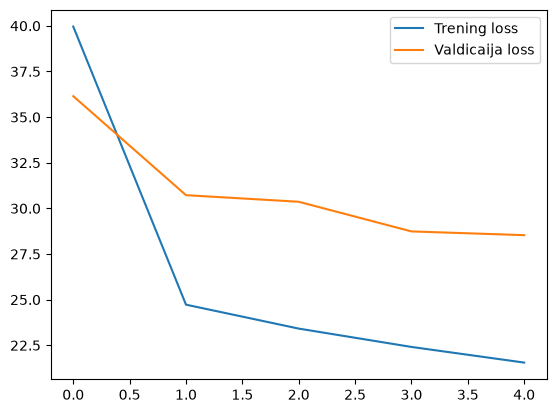

In [61]:
plt.figure()
plt.plot(train_losses, label="Trening loss")
plt.plot(val_losses, label="Valdicaija loss")
plt.legend()
plt.show()

In [ ]:
torch.save(model.state_dict(), f"modeli/lstm_{num_layers}.pt")

In [58]:
# Predikcije u buducnost
model.eval()
predictions = []
time_steps = 1000
with torch.no_grad():
    current_temps = X_train[-1, :, :]
    for i in tqdm.tqdm(range(time_steps)):
        next_temp = model(current_temps.unsqueeze(0))
        predictions.append(next_temp[:, -1, :])
        current_temps = torch.roll(current_temps, -1)
        current_temps[-1] = next_temp[:, -1, :]

100%|██████████| 1000/1000 [00:06<00:00, 146.35it/s]


In [59]:
#predictions = np.array(predictions.squeeze())
predictions = torch.cat(predictions, dim=0).squeeze().numpy()

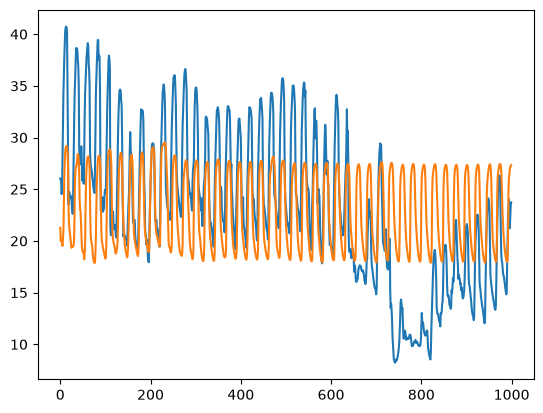

In [60]:
plt.figure()
plt.plot(validacija[:time_steps])
plt.plot(predictions)